In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
df=pd.read_csv(r"C:\Users\Parth\Desktop\VertexPlus\Solar power dataset.csv")

In [3]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
from datetime import datetime


def try_parsing_date(x):
    # If it's already a Timestamp or datetime, just return it
    if isinstance(x, (pd.Timestamp, datetime)):
        return x
    
    # Otherwise, try parsing as string
    tp = ('%d-%m-%Y %H:%M', '%m/%d/%Y %H:%M')
    try:
        return datetime.strptime(str(x), tp[0])
    except Exception as e:
        return datetime.strptime(str(x), tp[1])

df['DATE_TIME'] = df['DATE_TIME'].apply(try_parsing_date)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [6]:
df.drop(columns=['PLANT_ID','SOURCE_KEY'],inplace=True)

In [7]:
df.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,0.0,0.0,0.0,6259559.0
1,2020-05-15,0.0,0.0,0.0,6183645.0
2,2020-05-15,0.0,0.0,0.0,6987759.0
3,2020-05-15,0.0,0.0,0.0,7602960.0
4,2020-05-15,0.0,0.0,0.0,7158964.0


In [8]:
df.set_index('DATE_TIME',inplace=True)

In [9]:
df.head()

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,,,,
2020-05-15,0.0,0.0,0.0,6259559.0
2020-05-15,0.0,0.0,0.0,6183645.0
2020-05-15,0.0,0.0,0.0,6987759.0
2020-05-15,0.0,0.0,0.0,7602960.0
2020-05-15,0.0,0.0,0.0,7158964.0


In [10]:
df=df.groupby('DATE_TIME').mean()

In [11]:
df.head()

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,,,,
2020-01-06 00:00:00,0.0,0.0,245.784091,6.978158e+06
2020-01-06 00:15:00,0.0,0.0,0.000000,6.978158e+06
2020-01-06 00:30:00,0.0,0.0,0.000000,6.978158e+06
2020-01-06 00:45:00,0.0,0.0,0.000000,6.978158e+06
2020-01-06 01:00:00,0.0,0.0,0.000000,6.978158e+06


In [12]:
features = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
target_column = 'TOTAL_YIELD'

In [13]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

In [14]:
def create_sequences(data, seq_len, target_index):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])  # All features
        y.append(data[i+seq_len, target_index])  # Predict next total yield
    return np.array(X), np.array(y)

seq_len = 13 # past 6 hours (15 min interval)
target_index = features.index(target_column)
X, y = create_sequences(scaled, seq_len, target_index)

In [15]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [16]:

model = Sequential([
    LSTM(64, input_shape=(seq_len, len(features)), return_sequences=True),  # First LSTM layer
    LSTM(32, return_sequences=False),  # Second LSTM layer

    Dense(64, activation='relu'),  # First dense hidden layer
    Dense(32, activation='relu'),  # Second dense hidden layer
    Dense(16, activation='relu'),  # Third dense hidden layer

    Dense(1)  # Output layer
])
model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 13, 64)              │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,817 (136.00 KB)

 Trainable params: 34,817 (136.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 0.0579 - val_loss: 0.0196
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0065 - val_loss: 0.0119
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 0.0020
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0042 - val_loss: 1.8327e-04
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0038 - val_loss: 5.7827e-04
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0037 - val_loss: 0.0012
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0040 - val_loss: 4.5121e-05
Epoch 9/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0038 - val_loss: 2.4453e-04
Epoch 10/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0036 - val_loss: 2.6830e-04
Epoch 11/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0035 - val_loss: 1.5774e-04
Epoch 12/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 

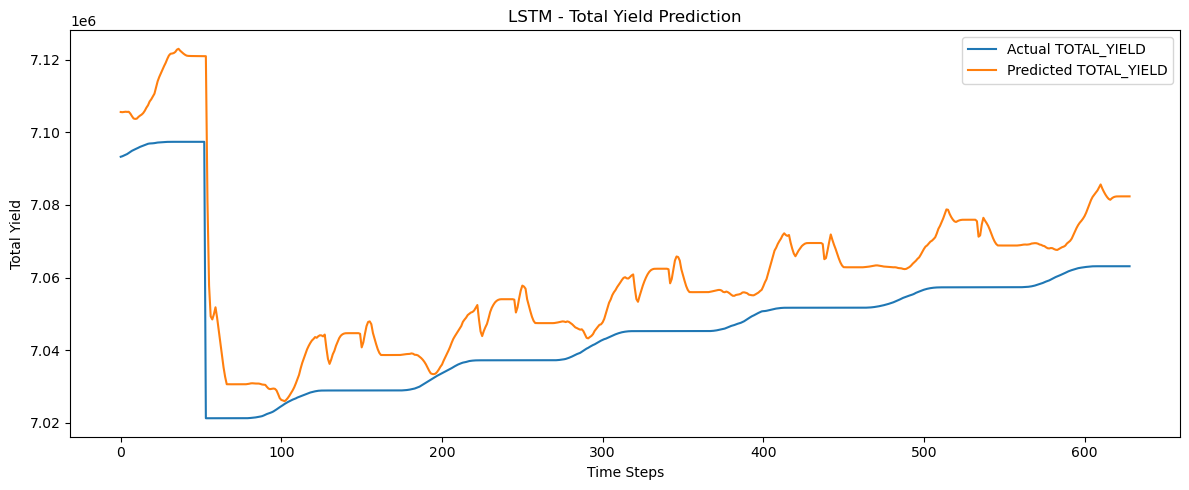

In [17]:
# 8. Train the model
model.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.1)

# 9. Make predictions
y_pred = model.predict(X_test)

# 10. Inverse transform predictions and actuals
target_scaler = MinMaxScaler()
target_scaler.min_, target_scaler.scale_ = scaler.min_[target_index:target_index+1], scaler.scale_[target_index:target_index+1]
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# 11. Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual TOTAL_YIELD')
plt.plot(y_pred_actual, label='Predicted TOTAL_YIELD')
plt.title("LSTM - Total Yield Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Total Yield")
plt.legend()
plt.tight_layout()
plt.show()

TRANSFORMER

In [18]:
X.shape

(3145, 13, 4)

In [19]:
y.shape

(3145,)

In [20]:
def create_sequences(data, seq_len, target_index):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])  # All features
        y.append(data[i+seq_len, target_index])  # Predict next total yield
    return np.array(X), np.array(y)

seq_len = 23 
target_index = features.index(target_column)
X, y = create_sequences(scaled, seq_len, target_index)

In [21]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [22]:
import tensorflow as tf
import numpy as np

def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    # Apply sin to even indices, cos to odd
    pos_encoding = np.zeros(angle_rads.shape)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)


In [23]:
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Input, Layer
from tensorflow.keras.models import Model

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):  # <- Make 'training' optional
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
    
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


In [24]:
def build_transformer_model(seq_len, num_features, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = Input(shape=(seq_len, num_features))
    
    # Project inputs to embedding dimension
    x = Dense(embed_dim)(inputs)
    
    # Add positional encoding
    pos_encoding = get_positional_encoding(seq_len, embed_dim)
    x += pos_encoding
    
    # Transformer block
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(1)(x)  # Output layer for regression
    
    model = Model(inputs=inputs, outputs=x)
    return model


In [25]:
model = build_transformer_model(seq_len=23, num_features=4)
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train
model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=64)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 23, 4)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 23, 64)              │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 23, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ (None, 23, 64)              │          83,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 87,745 (342.75 KB)

 Trainable params: 87,745 (342.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.0943 - val_loss: 0.0899
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0130 - val_loss: 0.0275
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0084 - val_loss: 0.0174
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0066 - val_loss: 0.0079
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0050 - val_loss: 0.0027
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0041 - val_loss: 0.0090
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0045 - val_loss: 0.0027
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0049 - val_loss: 0.0035
Epoch 10/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0046 - val_loss: 0.0023
Epoch 11/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 12/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0

In [26]:
y_pred = model.predict(X_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [27]:
y_pred = y_pred.flatten()
y_test = y_test.flatten()


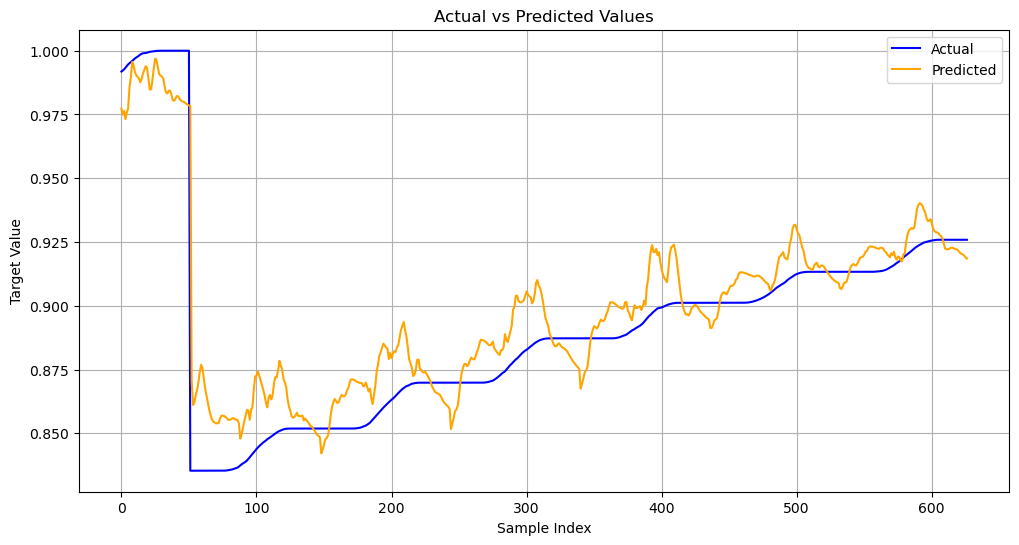

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='orange')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

